# Neurosignature Analysis: Simple CTRNN

Walks through the full analysis pipeline for the simplest non-trivial model:
- 16 hidden units, 3 inputs, 4 outputs
- Poisson synaptic inputs convolved with alpha kernel
- Per-channel statistics, global statistics, spectral statistics
- Full descriptor assembly via DescriptorAssembler

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurosignature as ns
from neurosignature.summaries import (
    compute_channel_statistics,
    compute_global_statistics,
    compute_spectral_statistics,
    DescriptorAssembler,
)

np.random.seed(0)
sns.set_context("notebook")
plt.rcParams["axes.formatter.useoffset"] = False

## 1. Model Setup

In [2]:
n_hidden = 16
n_inputs = 3
n_outputs = 4

W_int = ns.generate_random_matrix(n_hidden, n_hidden, dist="normal", matrix_type="symmetric")
W_prop = ns.generate_random_matrix(n_hidden, n_hidden, dist="normal", matrix_type="symmetric")
W_u = ns.relu(ns.generate_random_matrix(n_hidden, n_inputs, dist="normal", matrix_type="dense"))
W_o = ns.relu(ns.generate_random_matrix(n_outputs, n_hidden, dist="normal", matrix_type="dense"))

system = ns.ContinuousTimeRNN(
    n_hidden=n_hidden,
    n_inputs=n_inputs,
    n_outputs=n_outputs,
    W_int=W_int,
    W_prop=W_prop,
    W_u=W_u,
    W_o=W_o,
    g=0.5,
    tau=0.1,
    V_rest=-65.0,
    polarity="excitatory",
    phi="tanh",
)

print(system)

## 2. Generate Inputs & Run Simulation

In [3]:
input_gen = ns.InputGenerator(
    n_channels=system.n_inputs,
    rate_hz=50.0,
    tau_ms=2.0,
    dt_ms=0.1,
)

duration_ms = 300
currents = input_gen.generate(duration_ms=duration_ms)

simulator = ns.Simulator(system, dt_ms=0.1)
outputs, states = simulator.run(currents, record_states=True)

time = np.arange(len(outputs)) * simulator.dt_ms

print(f"Outputs shape : {outputs.shape}")
print(f"States shape  : {states.shape}")
print(f"Output range  : [{outputs.min():.3f}, {outputs.max():.3f}]")

Outputs shape : (3000, 4)
States shape  : (3000, 16)
Output range  : [-65.000, -64.472]


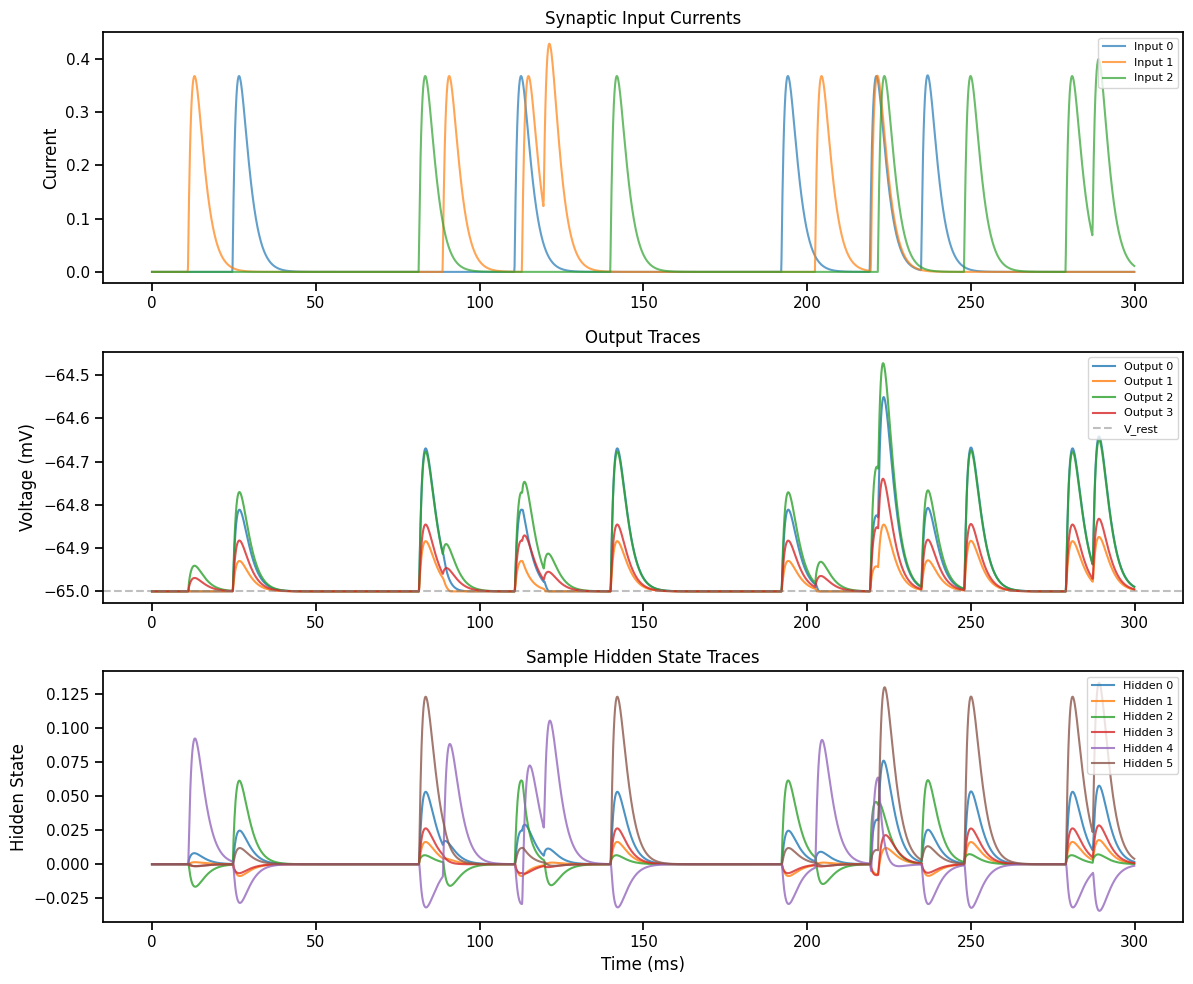

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

ax = axes[0]
for i in range(system.n_inputs):
    ax.plot(time, currents[:, i], label=f"Input {i}", alpha=0.7)
ax.set_ylabel("Current")
ax.set_title("Synaptic Input Currents")
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
for i in range(system.n_outputs):
    ax.plot(time, outputs[:, i], label=f"Output {i}", alpha=0.8)
ax.axhline(system.V_rest, color="gray", linestyle="--", alpha=0.5, label="V_rest")
ax.set_ylabel("Voltage (mV)")
ax.set_title("Output Traces")
ax.legend(loc="upper right", fontsize=8)

ax = axes[2]
for i in range(min(6, system.n_hidden)):
    ax.plot(time, states[:, i], label=f"Hidden {i}", alpha=0.8)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Hidden State")
ax.set_title("Sample Hidden State Traces")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## 3. Per-Channel Statistics

Mean, variance, std, RMS, skewness, kurtosis — one value per output channel.

In [5]:
ch_stats = compute_channel_statistics(outputs)

for key, vals in ch_stats.items():
    print(f"{key:12s}: {np.array2string(vals, precision=4, suppress_small=True)}")

mean        : [-64.9478 -64.9817 -64.9376 -64.9692]
variance    : [0.0087 0.0011 0.0098 0.0024]
std         : [0.0932 0.0328 0.099  0.0485]
min         : [-65. -65. -65. -65.]
max         : [-64.5508 -64.8456 -64.4725 -64.7395]
rms         : [64.9478 64.9817 64.9377 64.9692]
skewness    : [1.9851 1.9459 1.9016 1.8878]
kurtosis    : [3.2086 2.9655 3.3214 3.3126]


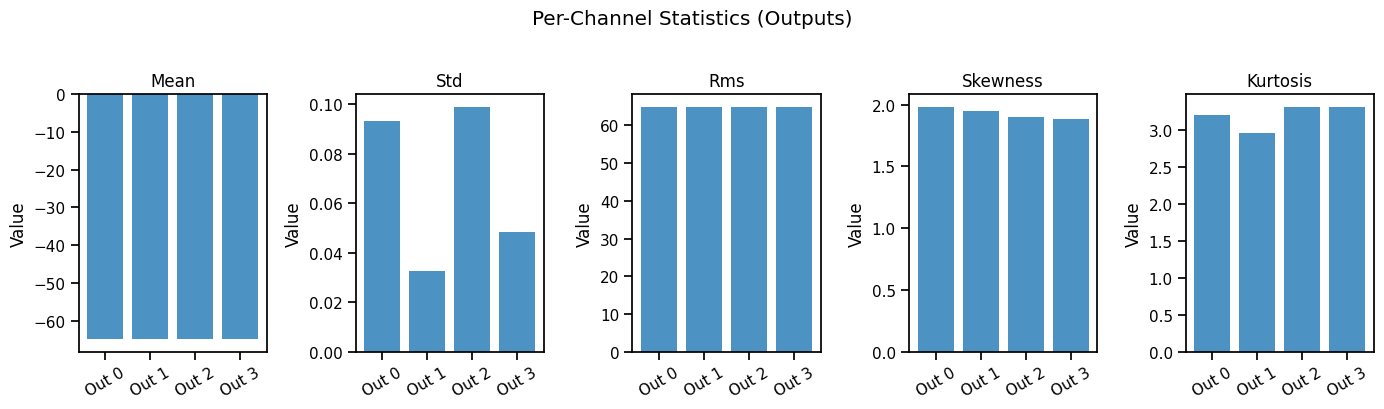

In [6]:
stat_keys = ["mean", "std", "rms", "skewness", "kurtosis"]
channel_labels = [f"Out {i}" for i in range(n_outputs)]

fig, axes = plt.subplots(1, len(stat_keys), figsize=(14, 4))

for ax, key in zip(axes, stat_keys):
    ax.bar(channel_labels, ch_stats[key], alpha=0.8)
    ax.set_title(key.capitalize())
    ax.set_ylabel("Value")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Per-Channel Statistics (Outputs)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Global Statistics

Cross-channel correlations, covariance eigenspectrum, mean autocorrelation.

In [7]:
gl_stats = compute_global_statistics(outputs, max_lag=100)

print("Correlation matrix:")
print(np.round(gl_stats["correlation_matrix"], 3))
print("\nCovariance eigenvalues (descending):")
print(np.round(gl_stats["covariance_eigenvalues"], 4))
print("\nApproximate entropy per channel:")
print(np.round(gl_stats["approximate_entropy"], 4))

Correlation matrix:
[[1.    0.999 0.976 0.969]
 [0.999 1.    0.972 0.965]
 [0.976 0.972 1.    0.999]
 [0.969 0.965 0.999 1.   ]]

Covariance eigenvalues (descending):
[0.0216 0.0003 0.     0.    ]

Approximate entropy per channel:
[0.0202 0.0204 0.0216 0.0218]


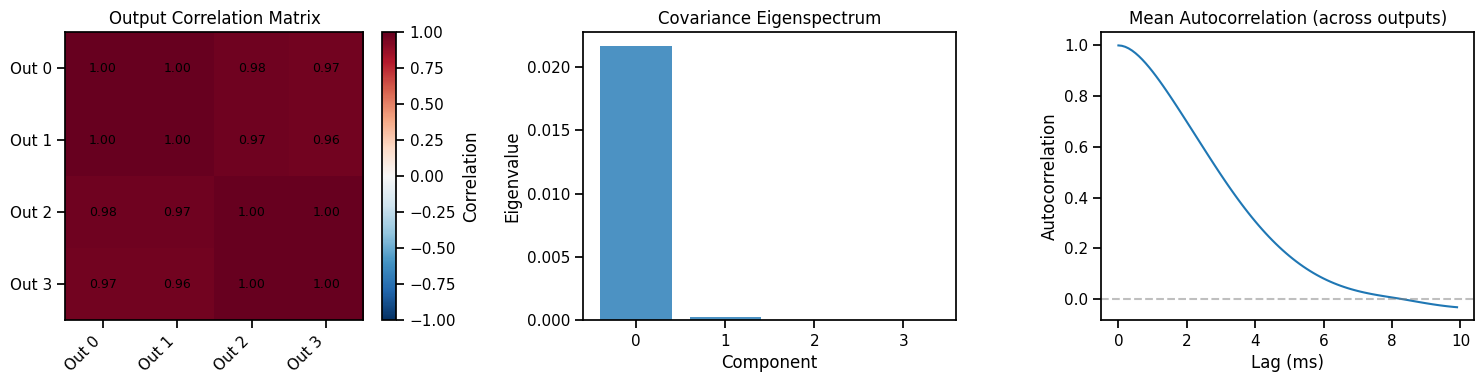

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Correlation matrix heatmap
ax = axes[0]
corr = gl_stats["correlation_matrix"]
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(n_outputs))
ax.set_yticks(range(n_outputs))
ax.set_xticklabels(channel_labels, rotation=45, ha="right")
ax.set_yticklabels(channel_labels)
for i in range(n_outputs):
    for j in range(n_outputs):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Output Correlation Matrix")

# Covariance eigenspectrum
ax = axes[1]
eigs = gl_stats["covariance_eigenvalues"]
ax.bar(range(len(eigs)), eigs, alpha=0.8)
ax.set_xlabel("Component")
ax.set_ylabel("Eigenvalue")
ax.set_title("Covariance Eigenspectrum")

# Mean autocorrelation
ax = axes[2]
autocorr = gl_stats["autocorrelation_mean"]
lags = np.arange(len(autocorr)) * simulator.dt_ms
ax.plot(lags, autocorr, linewidth=1.5)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Mean Autocorrelation (across outputs)")

plt.tight_layout()
plt.show()

## 5. Spectral Statistics

FFT-based: dominant frequencies, spectral centroids, band powers, spectral entropy.

In [9]:
sp_stats = compute_spectral_statistics(outputs, dt_ms=simulator.dt_ms, n_dominant_freqs=5)

print("Dominant frequencies (Hz) per output channel:")
print(np.round(sp_stats["dominant_frequencies"], 2))
print("\nSpectral centroid (Hz) per channel:")
print(np.round(sp_stats["spectral_centroid"], 2))
print("\nSpectral entropy per channel:")
print(np.round(sp_stats["spectral_entropy"], 3))
print("\nBand powers [0-10, 10-50, 50-100 Hz] per channel:")
print(np.round(sp_stats["band_powers"], 2))

Dominant frequencies (Hz) per output channel:
[[36.67 20.   30.   73.33 33.33]
 [36.67 20.   30.   73.33 33.33]
 [36.67 30.   20.   73.33  6.67]
 [36.67 30.   20.   73.33 66.67]]

Spectral centroid (Hz) per channel:
[56.55 57.14 56.42 56.69]

Spectral entropy per channel:
[4.834 4.856 4.871 4.883]

Band powers [0-10, 10-50, 50-100 Hz] per channel:
[[3.79639068e+10 1.89189500e+04 1.04346200e+04]
 [3.80035539e+10 2.30090000e+03 1.32723000e+03]
 [3.79520161e+10 2.15592800e+04 1.18180700e+04]
 [3.79890059e+10 5.14747000e+03 2.86769000e+03]]


TypeError: no implementation found for 'numpy.fft.rfft' on types that implement __array_function__: [<class 'pynapple.core.time_series.Tsd'>]

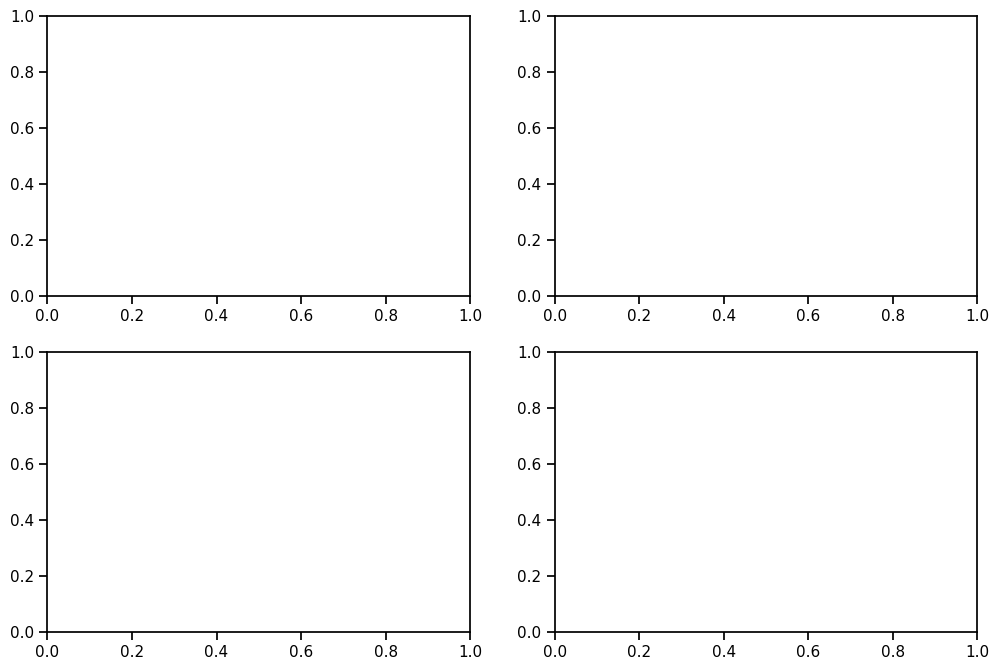

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Power spectra for each output channel
ax = axes[0, 0]
freqs_plot = np.fft.rfftfreq(len(outputs), d=simulator.dt_ms / 1000.0)
for i in range(n_outputs):
    power = np.abs(np.fft.rfft(outputs[:, i])) ** 2
    ax.semilogy(freqs_plot[1:], power[1:], label=f"Out {i}", alpha=0.8)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (log)")
ax.set_title("Power Spectra")
ax.set_xlim([0, 500])
ax.legend(fontsize=8)

# Spectral centroid per channel
ax = axes[0, 1]
ax.bar(channel_labels, sp_stats["spectral_centroid"], alpha=0.8)
ax.set_ylabel("Centroid (Hz)")
ax.set_title("Spectral Centroid per Channel")
ax.tick_params(axis="x", rotation=30)

# Band powers heatmap
ax = axes[1, 0]
band_labels = ["0–10 Hz", "10–50 Hz", "50–100 Hz"]
im = ax.imshow(sp_stats["band_powers"].T, aspect="auto", cmap="viridis")
ax.set_xticks(range(n_outputs))
ax.set_yticks(range(3))
ax.set_xticklabels(channel_labels)
ax.set_yticklabels(band_labels)
plt.colorbar(im, ax=ax, label="Power")
ax.set_title("Band Powers")

# Spectral entropy per channel
ax = axes[1, 1]
ax.bar(channel_labels, sp_stats["spectral_entropy"], alpha=0.8, color="tab:orange")
ax.set_ylabel("Entropy (bits)")
ax.set_title("Spectral Entropy per Channel")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 6. Full Descriptor Vector

`DescriptorAssembler` combines all statistics (basic + spectral) into a single
fixed-dimensional vector S(F_θ) ∈ R^K.

In [ ]:
assembler = DescriptorAssembler(
    top_k_eigenvalues=4,   # keep all 4 output eigenvalues
    n_autocorr_lags=20,
    n_dominant_freqs=5,
    include_spectral=True,
)

descriptor = assembler.compute_descriptor(outputs, dt_ms=simulator.dt_ms)
info = assembler.get_descriptor_info(n_channels=n_outputs)

print(f"Descriptor dimension: {len(descriptor)}")
print("\nDimension breakdown:")
for k, v in info.items():
    print(f"  {k}: {v}")

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

ax = axes[0]
ax.plot(descriptor, linewidth=0.8, color="steelblue")
ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Descriptor index")
ax.set_ylabel("Value")
ax.set_title(f"Full Descriptor Vector  (dim={len(descriptor)})")

ax = axes[1]
ax.bar(range(len(descriptor)), np.abs(descriptor), width=1.0, alpha=0.7, color="steelblue")
ax.set_xlabel("Descriptor index")
ax.set_ylabel("|Value|")
ax.set_title("Descriptor Magnitudes")

plt.tight_layout()
plt.show()